# 6. Florence-2 Zero-Shot Visual Experiments
Florence-2 is Microsoft's advanced unified vision-language model. It performs multiple tasks (Object Detection, Captioning, Grounding) using textual prompt formatting.

In this notebook, we:
1. Load Florence-2.
2. Run standard `<OD>` (general object detection).
3. Run `<CAPTION_TO_PHRASE_GROUNDING>` (phrase grounding for specific fashion items).
4. Compare results.



In [1]:
import os
import sys

sys.path.append(os.path.abspath("."))

from fashion_detector.config import Config
from fashion_detector.models.florence2 import Florence2Detector
from fashion_detector.utils import (
    load_image,
    generate_interactive_html,
    visualize_detections,
)
from IPython.display import HTML

config = Config("config/config.yaml")

# Initialize Florence-2
detector = Florence2Detector(config)
detector.load_model()

/Users/sunnyraj/code_files/git_repos/image-segments/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-07-21 18:15:32] [INFO] [fashion_detector:config.py:159] - Configuration loaded from config/config.yaml. Device set to: mps
[2026-07-21 18:15:32] [INFO] [fashion_detector:florence2.py:44] - Florence-2 Detector initialized with model: microsoft/Florence-2-base, confidence threshold: 0.3
[2026-07-21 18:15:32] [INFO] [fashion_detector:florence2.py:47] - Florence-2 Detector default lifestyle categories: ['shirt', 't-shirt', 'polo', 'sweater', 'hoodie', 'jacket', 'blazer', 'coat', 'dress', 'top', 'jeans', 'pants', 'shorts', 'skirt', 'suit', 'jumpsuit', 'scarf', 'handbag', 'backpack', 'wallet', 'belt', 'watch', 'bracelet', 'necklace', 'earrings', 'ring', 'hat', 'cap', 'sunglasses', 'shoes', 'boots', 'sneakers']
[2026-07-21 18:15:32] [INFO] [fashion_detector:florence2.py:59] - Loading Florence-2 model: microsoft/Florence-2-base on device: mps


`torch_dtype` is deprecated! Use `dtype` instead!


[2026-07-21 18:15:40] [INFO] [fashion_detector:florence2.py:143] - Florence-2 model loaded successfully.


## Task 1: General Object Detection (`<OD>`)
This task automatically outputs boxes and names without specifying categories.



In [2]:
image = load_image("data/fashion_model_street.jpg")
detections_od = detector.detect(image, task="<OD>")

print("Florence-2 <OD> Detections:")
for d in detections_od:
    print(f"- {d.label}: box={list(map(int, d.box))}")

[2026-07-21 18:15:43] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: data/fashion_model_street.jpg
[2026-07-21 18:15:43] [INFO] [fashion_detector:logging.py:98] - Starting: Florence-2 Inference
[2026-07-21 18:15:43] [INFO] [fashion_detector:florence2.py:174] - Florence-2 running task: <OD>
[2026-07-21 18:15:44] [INFO] [fashion_detector:florence2.py:282] - Florence-2 detected 3 fashion items (filtered from 5 total).
[2026-07-21 18:15:44] [INFO] [fashion_detector:logging.py:103] - Completed: Florence-2 Inference in 1.7160 seconds
Florence-2 <OD> Detections:
- shoes: box=[271, 906, 342, 1024]
- shoes: box=[518, 886, 575, 1017]
- pants: box=[279, 378, 584, 916]


## Task 2: Phrase Grounding (`<CAPTION_TO_PHRASE_GROUNDING>`)
We ask the model to look specifically for our fashion categories.



In [3]:
fashion_queries = ["dress", "hat", "handbag", "sunglasses", "shoes"]
detections_grounding = detector.detect(
    image, task="<CAPTION_TO_PHRASE_GROUNDING>", queries=fashion_queries
)

print("Florence-2 Phrase Grounding Detections:")
for d in detections_grounding:
    print(f"- {d.label}: box={list(map(int, d.box))}")

[2026-07-21 17:39:36] [INFO] [fashion_detector:logging.py:98] - Starting: Florence-2 Inference
[2026-07-21 17:39:36] [INFO] [fashion_detector:florence2.py:163] - Florence-2 running task: <CAPTION_TO_PHRASE_GROUNDING>
[2026-07-21 17:39:37] [INFO] [fashion_detector:florence2.py:271] - Florence-2 detected 3 fashion items (filtered from 3 total).
[2026-07-21 17:39:37] [INFO] [fashion_detector:logging.py:103] - Completed: Florence-2 Inference in 0.7923 seconds
Florence-2 Phrase Grounding Detections:
- dress: box=[263, 64, 588, 1023]
- dress: box=[264, 142, 587, 913]
- sunglasses: box=[362, 93, 439, 122]


## Visualize Grounding Detections


[2026-07-21 18:15:47] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: /Users/sunnyraj/Downloads/images-2.jpeg
[2026-07-21 18:15:47] [INFO] [fashion_detector:logging.py:98] - Starting: Florence-2 Inference
[2026-07-21 18:15:47] [INFO] [fashion_detector:florence2.py:174] - Florence-2 running task: <CAPTION_TO_PHRASE_GROUNDING>
[2026-07-21 18:15:47] [INFO] [fashion_detector:florence2.py:282] - Florence-2 detected 1 fashion items (filtered from 1 total).
[2026-07-21 18:15:47] [INFO] [fashion_detector:logging.py:103] - Completed: Florence-2 Inference in 0.5384 seconds



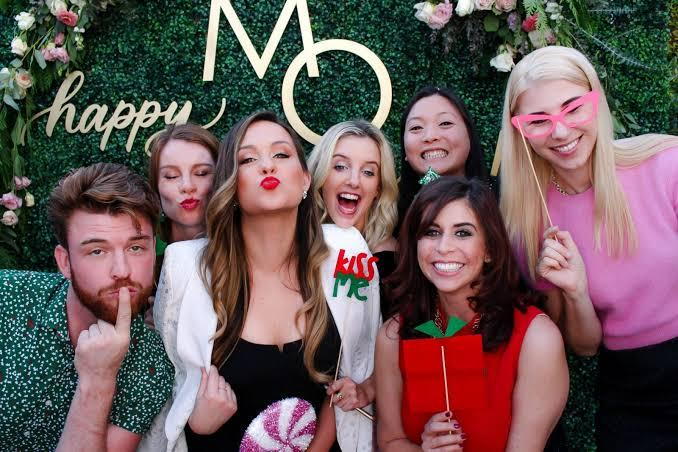

In [3]:
cats = [
    "dresses",
    "tops",
    "sweaters",
    "shirts",
    "jackets blazers",
    "coats",
    "pants",
    "jeans",
    "skirts",
    "suits sets",
    "jumpsuits",
    "sneakers",
    "flats",
    "loafers",
    "mules slides",
    "heels",
    "sandals",
    "boots",
    "tote bags",
    "shoulder bags",
    "crossbody bags",
    "handle bags",
    "backpacks",
    "belt bags",
    "clutches",
    "sunglasses",
    "scarves shawls",
    "belts",
    "wallets",
    "hats",
    "watches",
    "jewelry",
    "earrings",
    "necklaces",
    "bracelets",
    "rings",
    "brooches",
    "t shirts",
    "shirts",
    "sweaters",
    "jackets",
    "blazers",
    "coats",
    "pants",
    "jeans",
    "suits",
    "shorts",
    "dress shoes",
    "loafers",
    "sneakers",
    "boots",
    "sandals",
    "briefcases",
    "backpacks",
    "duffel bags",
    "messenger bags",
    "tote bags",
    "sunglasses",
    "belts",
    "ties",
    "scarves",
    "wallets",
    "hats",
    "watches",
]
image_path = "/Users/sunnyraj/Downloads/images-2.jpeg"
image = load_image(image_path)
detected_products = detector.detect(
    image, task="<CAPTION_TO_PHRASE_GROUNDING>", queries=["shirt"]
)
visualize_detections(image, detector._to_dict(detected_products))

In [4]:
# Run raw tag matching check
detected_categories = detector.extract_present_classes(image, list(set(cats)))
print(f"Verified items found in the image matrix: {detected_categories}")

[2026-07-21 18:15:50] [INFO] [fashion_detector:logging.py:98] - Starting: Florence-2 Pure Class Presence Extraction
[2026-07-21 18:15:52] [INFO] [fashion_detector:florence2.py:359] - Verified Image Canvas Text Footprint: the image shows a group of people posing for a photo in front of a green wall adorned with flowers and leaves. some of the people are wearing glasses and one person is holding something in their hand. there is also a board with text in the background.
[2026-07-21 18:15:52] [INFO] [fashion_detector:logging.py:103] - Completed: Florence-2 Pure Class Presence Extraction in 2.6719 seconds
Verified items found in the image matrix: ['rings']


In [ ]:
import pandas as pd

pd.DataFrame(detector._to_dict(detected_products))

,box,label,score,has_mask,metadata
0,"[262.0, 65.86650085449219, 590.0, 1024.5284423...",dress,1.0,False,{'raw_label': 'dresses'}
1,"[263.6000061035156, 146.67750549316406, 538.79...",jacket,1.0,False,{'raw_label': 'jackets'}
2,"[263.6000061035156, 148.89149475097656, 537.20...",jacket,1.0,False,{'raw_label': 'jackets'}
3,"[278.8000183105469, 378.0404968261719, 588.400...",skirt,1.0,False,{'raw_label': 'skirts'}
4,"[278.8000183105469, 378.0404968261719, 587.600...",skirt,1.0,False,{'raw_label': 'skirts'}
5,"[278.8000183105469, 379.1474914550781, 587.600...",skirt,1.0,False,{'raw_label': 'skirts'}
6,"[519.6000366210938, 881.7255249023438, 568.400...",bracelet,1.0,False,{'raw_label': 'bracelets'}
7,"[270.8000183105469, 903.865478515625, 342.8000...",boots,1.0,False,{'raw_label': 'boots'}
8,"[270.8000183105469, 903.865478515625, 342.0, 1...",boots,1.0,False,{'raw_label': 'boots'}
9,"[517.2000122070312, 882.83251953125, 576.40002...",boots,1.0,False,{'raw_label': 'boots'}



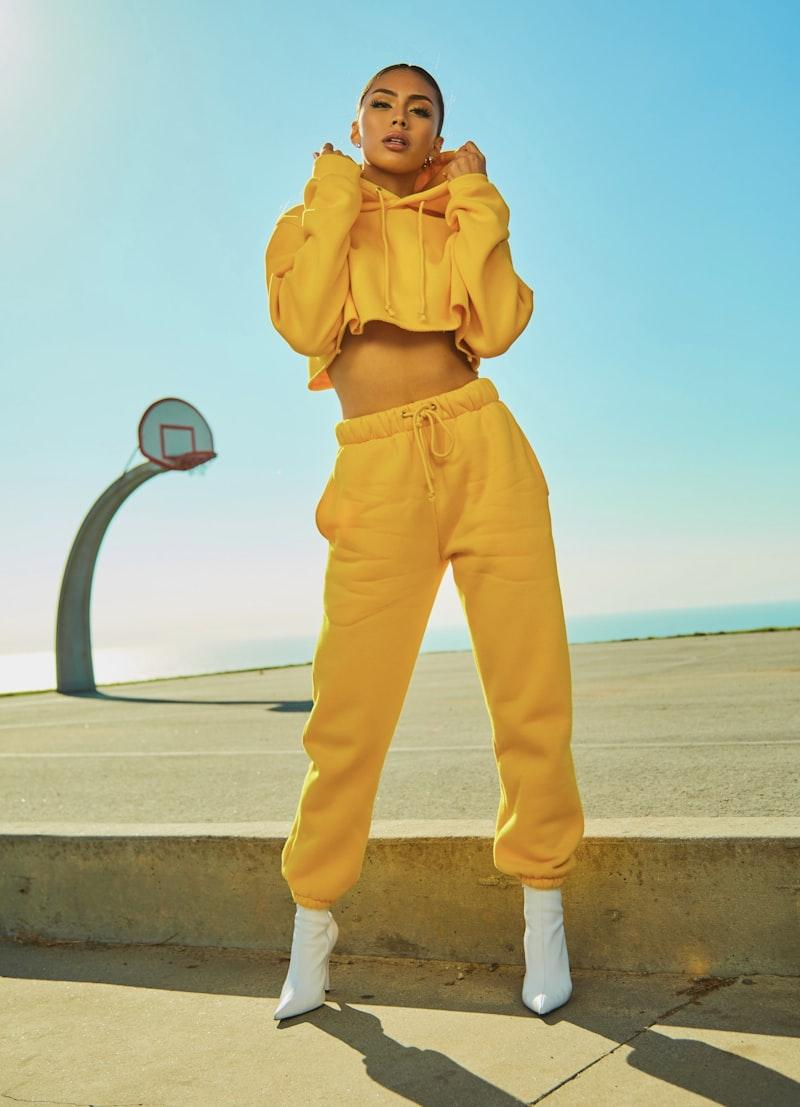

In [12]:
visualize_detections(image, detector._to_dict(detected_products))